# Preamble

In [1]:
!date

Tue Apr  1 13:51:21 PDT 2025


In [2]:
%load_ext autoreload
%load_ext line_profiler

In [3]:
import logging

logging.basicConfig(level=logging.INFO, force=True)

In [4]:
import os as _os

_os.chdir(_os.environ["PROJECT_ROOT"])

In [5]:
import os
from contextlib import contextmanager
from itertools import chain, product
from multiprocessing import Pool

import fastcluster
import graph_tool as gt
import graph_tool.draw
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
import strainzip as sz
import strainzip.app.unzip
import xarray as xr
from graph_tool.util import find_edge
from scipy.cluster.hierarchy import fcluster, linkage
from strainzip.pandas_util import idxwhere
from tqdm import tqdm

import lib.plot

# Params

## Plotting

In [6]:
mpl.rcParams["figure.dpi"] = 100
# sns.set_context('talk')

In [7]:
# Plotting parameters

length_bins = np.logspace(0, 6.5, num=51)
depth_bins = np.logspace(-1, 4, num=51)

linestyle_palette = {"megahit": "--", "strainzip": "-"}
facecolor_palette = {"megahit": "none", "strainzip": "auto"}

draw_graphs = True

## Project params

In [8]:
k = 111
group = "btheta_mixture1_cov10000"  # "xjin_test6"  # "btheta_mixture1_cov10000"  # "btheta_mixture1_cov1000"
graph_type = f"k{k}-withmegahit3-droptips"
smoothing = "smoothed-6"
deconv = "norm-nobal-nocull-10-10"
marker_model_list = ["TIGR00952_1", "TIGR01063_1", "TIGR02013_1"]

In [9]:
# benchmark = "all_ref_tiles-k5000-o3000"
# benchmark = "all_ref_tiles-k10000-o5000"
# benchmark = "all_ref_tiles-k50000-o30000"
benchmark = "all_ref_cds"

coverage_thresh = 1.0

In [10]:
thresh_list = [
    ("0_identical", 1.0, coverage_thresh),
    ("1_veryhigh", 0.999, coverage_thresh),
    ("2_high", 0.995, coverage_thresh),
    ("3_medium", 0.99, coverage_thresh),
    ("4_verylow", 0.98, coverage_thresh),
]

# Load Data

## Load Metadata

In [11]:
mgen_group = (
    pd.read_table("meta/mgen_group.tsv")[lambda x: x.mgen_group == group]
    .assign(community_id=lambda x: x.mgen_id.str.split("_simcom_").str[0])
    .set_index("mgen_id")
)


mgen_group

,mgen_group,community_id
mgen_id,,
btheta_strainA_simcom_len150_seed0_cov10000,btheta_mixture1_cov10000,btheta_strainA
btheta_strainB_simcom_len150_seed0_cov10000,btheta_mixture1_cov10000,btheta_strainB
btheta_mixture_50_50_simcom_len150_seed1_cov10000,btheta_mixture1_cov10000,btheta_mixture_50_50
btheta_mixture_25_75_simcom_len150_seed2_cov10000,btheta_mixture1_cov10000,btheta_mixture_25_75
btheta_mixture_75_25_simcom_len150_seed3_cov10000,btheta_mixture1_cov10000,btheta_mixture_75_25


In [12]:
# Build up the sample palette to generalize it across the multiple use cases of this notebook.

sample_palette = lib.plot.construct_ordered_palette(
    [
        "btheta_strainA_simcom_len150_seed0_cov1000",
        "btheta_mixture_75_25_simcom_len150_seed3_cov1000",
        "btheta_mixture_50_50_simcom_len150_seed1_cov1000",
        "btheta_mixture_25_75_simcom_len150_seed2_cov1000",
        "btheta_strainB_simcom_len150_seed0_cov1000",
    ],
    cm="coolwarm",
)
sample_palette = lib.plot.construct_ordered_palette(
    [
        "btheta_strainA_simcom_len150_seed0_cov10000",
        "btheta_mixture_75_25_simcom_len150_seed3_cov10000",
        "btheta_mixture_50_50_simcom_len150_seed1_cov10000",
        "btheta_mixture_25_75_simcom_len150_seed2_cov10000",
        "btheta_strainB_simcom_len150_seed0_cov10000",
    ],
    cm="coolwarm",
    extend=sample_palette,
)

sample_palette = lib.plot.construct_ordered_palette(
    mgen_group.index, extend=sample_palette, cm="coolwarm",
)

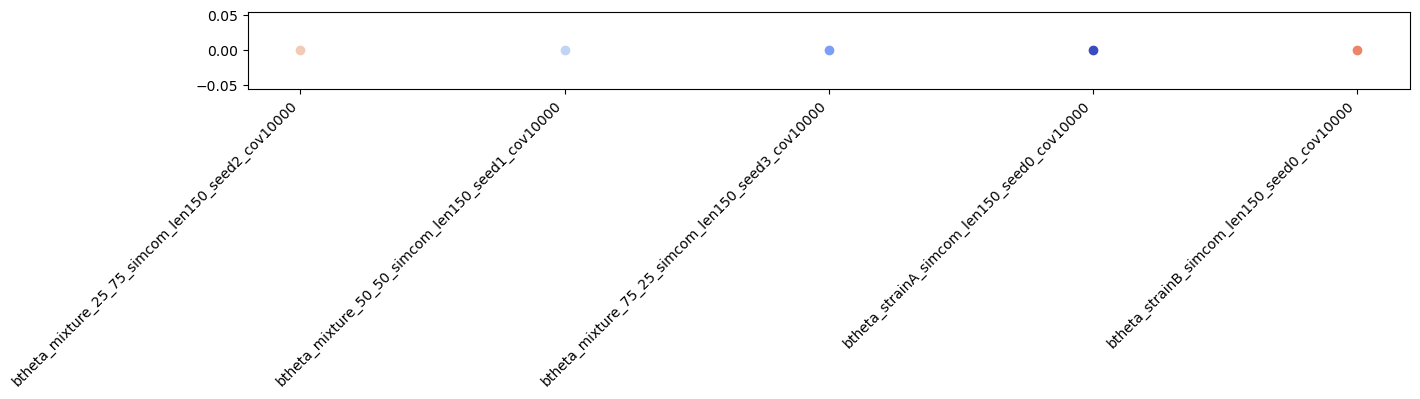

In [13]:
# Build up the sample palette to generalize it across the multiple use cases of this notebook.

fig = plt.figure(figsize=(15, 1))
d = mgen_group.index.to_series().sort_values().map(sample_palette)#.rename('c').reset_index().assign(y=np.arange(len(mgen_group))).set_index('mgen_id')
for i, (m, c) in enumerate(d.items()):
    plt.scatter(i, 0, color=c)
plt.xticks(np.arange(len(d)), d.index)
lib.plot.rotate_xticklabels()

In [14]:
genome_details = pd.read_table("meta/genome_group.tsv")[
    lambda x: x.genome_group_id == group
].assign(
    strain_id=lambda x: x.genome_id.str.rsplit("_").str[0],
)
genome_to_strain = genome_details.set_index("genome_id").strain_id
strain_to_genome = genome_details.set_index("strain_id").genome_id

In [15]:
if group.startswith("xjin"):
    kraken_read_counts = (
        pd.read_csv(
            "/pollard/home/xiaofanj/microbiomeAdhesion/intermediates/biofilmBeadExpV2/customKrakenOutputs/customKraken2BrackenAbundances.csv"
        )
        .set_index(["Strain_Name", "sample"])
        .new_est_reads.unstack("Strain_Name", fill_value=0)
        .rename(index=lambda x: "xjin_" + x)
    )
    known_rabund = kraken_read_counts.rename(columns=strain_to_genome).divide(
        kraken_read_counts.sum(1), axis=0
    )
elif group.startswith("btheta_mixture1"):
    sim_fractions = (
        pd.read_table("meta/simulated_community.tsv")[
            lambda x: x.community_id.isin(mgen_group.community_id)
        ]
        .set_index(["community_id", "genome_id"])
        .fraction.unstack(fill_value=0)
    )
    known_rabund = (
        mgen_group[["community_id"]]
        .join(sim_fractions, on="community_id")
        .drop(columns=["community_id"])
        .rename_axis(index="sample")
    )
else:
    assert False, "FIXME: This group type doesn't have a known_rabund..."

assert np.allclose(known_rabund.sum(1), 1)
known_rabund

,Bacteroides-thetaiotaomicron-1-1-6_MAF-2,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2
sample,,
btheta_strainA_simcom_len150_seed0_cov10000,1.00,0.00
btheta_strainB_simcom_len150_seed0_cov10000,0.00,1.00
btheta_mixture_50_50_simcom_len150_seed1_cov10000,0.50,0.50
btheta_mixture_25_75_simcom_len150_seed2_cov10000,0.25,0.75
btheta_mixture_75_25_simcom_len150_seed3_cov10000,0.75,0.25


## Depth

### StrainZip

In [16]:
final_graph = sz.io.load_graph(
    f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.sz"
)

vertex_depth = (
    sz.results.depth_table(final_graph, final_graph.get_vertices())
    .T.rename_axis(index="vertex", columns="sample")
    .rename(columns=mgen_group.index.to_series().reset_index(drop=True))
)
vertex_depth

sample,btheta_strainA_simcom_len150_seed0_cov10000,btheta_strainB_simcom_len150_seed0_cov10000,btheta_mixture_50_50_simcom_len150_seed1_cov10000,btheta_mixture_25_75_simcom_len150_seed2_cov10000,btheta_mixture_75_25_simcom_len150_seed3_cov10000
vertex,,,,,
0,0.002801,20.909788,14.432378,17.217749,4.933301
1,21.225477,21.549647,21.056035,20.985911,21.439580
2,189.083761,169.226058,180.456513,175.939526,183.022416
3,20.390501,21.709940,20.815533,21.260662,22.095354
4,21.729285,0.013164,11.754879,5.423868,15.933922
...,...,...,...,...,...
4373,0.004593,0.000104,0.000431,0.074064,0.001199
4374,0.007363,0.014216,0.128279,0.178165,0.015578
4375,21.162505,0.000140,10.603128,5.208321,15.400095


### MEGAHIT/Bowtie2

In [17]:
megahit_gene_depth = pd.read_table(
    f"data/group/{group}/r.proc.megahit-full-k111.prodigal.gene_depth.tsv",
    names=["sample", "gene", "depth"],
    index_col=["sample", "gene"],
).depth.unstack("sample", fill_value=0)

In [18]:
megahit_contig_depth = pd.read_table(
    f"data/group/{group}/r.proc.megahit-full-k111.contig_depth.tsv",
    names=["sample", "contig", "depth"],
    index_col=["sample", "contig"],
).depth.unstack("sample", fill_value=0)

## Genes

### StrainZip

In [19]:
strainzip_gene = pd.read_table(
    f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.prodigal.bed",
    names=["vertex", "left", "right", "gene", "score", "strand"],
)
strainzip_gene

,vertex,left,right,gene,score,strand
0,0,0,126,0[0-126]+,0,+
1,10,2,149,10[2-149]-,0,-
2,100,0,78,100[0-78]+,0,+
3,100,122,218,100[122-218]+,0,+
4,1000,2,422,1000[2-422]-,0,-
...,...,...,...,...,...,...
56025,996,0,198,996[0-198]+,0,+
56026,996,267,441,996[267-441]+,0,+
56027,997,2,239,997[2-239]-,0,-
56028,998,0,705,998[0-705]+,0,+


#### Depth Markers

In [20]:
total_strainzip_marker_depth = {}

for marker_model in marker_model_list:
    strainzip_marker_gene_list = pd.read_table(
        f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.cds.tran.hmmer-{marker_model}-ga.tsv",
        names=["gene", "gene_name", "bitscore"],
    ).gene.tolist()

    # print(strainzip_marker_gene_list)

    total_strainzip_marker_depth[marker_model] = vertex_depth.loc[
        strainzip_gene[lambda x: x.gene.isin(strainzip_marker_gene_list)].vertex
    ].sum()

total_strainzip_marker_depth = pd.DataFrame(total_strainzip_marker_depth)
print(total_strainzip_marker_depth)

total_strainzip_marker_depth = total_strainzip_marker_depth.mean(1)
print(total_strainzip_marker_depth)

                                                   TIGR00952_1  TIGR01063_1  \
sample                                                                        
btheta_strainA_simcom_len150_seed0_cov10000          42.301555    42.615926   
btheta_strainB_simcom_len150_seed0_cov10000          42.598820    42.662538   
btheta_mixture_50_50_simcom_len150_seed1_cov10000    43.670596    41.954750   
btheta_mixture_25_75_simcom_len150_seed2_cov10000    42.792677    43.766251   
btheta_mixture_75_25_simcom_len150_seed3_cov10000    42.235145    43.091231   

                                                   TIGR02013_1  
sample                                                          
btheta_strainA_simcom_len150_seed0_cov10000          42.382561  
btheta_strainB_simcom_len150_seed0_cov10000          42.039448  
btheta_mixture_50_50_simcom_len150_seed1_cov10000    42.283470  
btheta_mixture_25_75_simcom_len150_seed2_cov10000    42.527854  
btheta_mixture_75_25_simcom_len150_seed3_cov10000    42.

In [21]:
strainzip_normalized_depth = (vertex_depth / total_strainzip_marker_depth).T
strainzip_normalized_depth

vertex,0,1,2,3,4,5,6,7,8,9,...,4368,4369,4370,4371,4372,4373,4374,4375,4376,4377
sample,,,,,,,,,,,,,,,,,,,,,
btheta_strainA_simcom_len150_seed0_cov10000,0.000066,0.500207,4.456018,0.480530,0.512080,0.491672,0.491096,0.000344,0.490462,0.000066,...,0.490967,0.001055,0.000108,0.000878,0.002074,0.000108,0.000174,0.498723,0.490965,0.000131
btheta_strainB_simcom_len150_seed0_cov10000,0.492765,0.507844,3.988020,0.511621,0.000310,1.566782,0.496041,0.492110,0.494554,0.492765,...,0.000002,0.497816,0.000003,0.000693,0.000193,0.000002,0.000335,0.000003,0.000003,0.000344
btheta_mixture_50_50_simcom_len150_seed1_cov10000,0.338500,0.493853,4.232465,0.488212,0.275701,0.958549,0.491942,0.139286,0.466003,0.338500,...,0.240033,0.250363,0.000010,0.002877,0.003988,0.000010,0.003009,0.248688,0.240034,0.003540
btheta_mixture_25_75_simcom_len150_seed2_cov10000,0.400144,0.487716,4.088866,0.494102,0.126052,1.181105,0.525043,0.401757,0.507966,0.400144,...,0.115528,0.356960,0.001724,0.010357,0.002006,0.001721,0.004141,0.121042,0.115528,0.004304
btheta_mixture_75_25_simcom_len150_seed3_cov10000,0.115500,0.501950,4.284977,0.517303,0.373050,0.712767,0.482676,0.120150,0.492257,0.115500,...,0.367560,0.139578,0.000028,0.000152,0.001743,0.000028,0.000365,0.360552,0.367560,0.000299


### MEGAHIT/Bowtie2

In [22]:
megahit_gene = pd.read_table(
    f"data/group/{group}/r.proc.megahit-full-k111.prodigal.bed",
    names=["vertex", "left", "right", "gene", "score", "strand"],
)
megahit_gene

,vertex,left,right,gene,score,strand
0,k111_1,1,946,k111_1[1-946]+,0,+
1,k111_1,1060,3490,k111_1[1060-3490]-,0,-
2,k111_1,3647,4160,k111_1[3647-4160]-,0,-
3,k111_10,1,1573,k111_10[1-1573]+,0,+
4,k111_10,1611,2472,k111_10[1611-2472]+,0,+
...,...,...,...,...,...,...
7315,k111_997,45019,47659,k111_997[45019-47659]-,0,-
7316,k111_997,47723,48362,k111_997[47723-48362]-,0,-
7317,k111_997,48456,49521,k111_997[48456-49521]+,0,+
7318,k111_997,49625,50330,k111_997[49625-50330]+,0,+


#### Depth Markers

In [23]:
total_megahit_marker_depth = {}

for marker_model in marker_model_list:
    megahit_marker_gene_list = pd.read_table(
        f"data/group/{group}/r.proc.megahit-full-k111.cds.tran.hmmer-{marker_model}-ga.tsv",
        names=["gene", "gene_name", "bitscore"],
    ).gene.tolist()

    total_megahit_marker_depth[marker_model] = megahit_gene_depth.loc[
        megahit_gene[lambda x: x.gene.isin(megahit_marker_gene_list)].gene
    ].sum()

total_megahit_marker_depth = pd.DataFrame(total_megahit_marker_depth)
print(total_megahit_marker_depth)

total_megahit_marker_depth = total_megahit_marker_depth.mean(1)
print(total_megahit_marker_depth)

                                                   TIGR00952_1  TIGR01063_1  \
sample                                                                        
btheta_mixture_25_75_simcom_len150_seed2_cov10000    94.062963   102.864183   
btheta_mixture_50_50_simcom_len150_seed1_cov10000    98.733333    96.575087   
btheta_mixture_75_25_simcom_len150_seed3_cov10000    94.622222   102.306558   
btheta_strainA_simcom_len150_seed0_cov10000         111.140741   100.156771   
btheta_strainB_simcom_len150_seed0_cov10000          99.233333   103.837796   

                                                   TIGR02013_1  
sample                                                          
btheta_mixture_25_75_simcom_len150_seed2_cov10000    97.841332  
btheta_mixture_50_50_simcom_len150_seed1_cov10000    99.018358  
btheta_mixture_75_25_simcom_len150_seed3_cov10000    99.458694  
btheta_strainA_simcom_len150_seed0_cov10000          99.125098  
btheta_strainB_simcom_len150_seed0_cov10000         100.

In [24]:
megahit_normalized_depth = (megahit_contig_depth / total_megahit_marker_depth).T
megahit_normalized_depth

contig,k111_1,k111_10,k111_100,k111_1001,k111_1002,k111_1003,k111_1004,k111_1006,k111_1007,k111_1008,...,k111_99,k111_990,k111_991,k111_992,k111_993,k111_994,k111_995,k111_996,k111_997,k111_998
sample,,,,,,,,,,,,,,,,,,,,,
btheta_mixture_25_75_simcom_len150_seed2_cov10000,0.683697,1.017498,0.000000,0.271450,1.009315,0.746778,0.735611,1.025890,0.993137,1.015836,...,0.577672,0.241524,0.700398,1.008585,0.969502,0.596835,0.597628,0.269749,0.996394,0.230520
btheta_mixture_50_50_simcom_len150_seed1_cov10000,0.738048,0.938921,0.000000,0.074547,0.645939,0.322156,0.355591,0.814354,0.597654,0.646121,...,0.557208,0.080778,0.415563,0.878211,0.610548,0.214430,0.302502,0.365498,0.877897,0.068424
btheta_mixture_75_25_simcom_len150_seed3_cov10000,0.899317,1.003221,0.006147,0.096456,0.984821,0.269618,0.248658,1.009506,0.962125,0.979818,...,0.517762,0.066109,0.254297,0.995443,0.898432,0.224840,0.168323,0.744069,1.012806,0.157021
btheta_strainA_simcom_len150_seed0_cov10000,0.899486,0.956034,0.023476,0.000000,0.910454,0.000000,0.000000,0.953271,0.977451,0.951797,...,0.345856,0.000000,0.001043,0.976533,0.900646,0.037599,0.000000,0.962345,0.967072,0.177423
btheta_strainB_simcom_len150_seed0_cov10000,0.530415,0.969399,0.000000,0.321902,0.898709,0.991061,0.956667,0.976290,0.949137,0.961280,...,0.742638,0.289641,0.981583,0.983564,0.991288,0.630211,0.843950,0.001890,0.970560,0.214790


# Sequence Matching

## BLASTn

In [25]:
benchmark_sequence_length = pd.read_table(
    f"data/group/{group}/{benchmark}.benchmark_sequences.nlength.tsv",
    names=["gene", "nlength"],
    index_col="gene",
).nlength
benchmark_sequence_length

gene
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1413]+            1413
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1554-2292]-          738
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[2576-5114]+         2538
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[5245-7927]+         2682
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[8139-9153]+         1014
                                                               ... 
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[30017-30524]-     507
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[30528-31236]-     708
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[31246-31456]-     210
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[31442-32009]-     567
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[31992-33039]-    1047
Name: nlength, Length: 10536, dtype: int64

In [26]:
bench_to_genome = benchmark_sequence_length.index.to_series().str.rsplit('_', n=1).str[0].rename('genome')
bench_to_genome

gene
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1413]+               Bacteroides-thetaiotaomicron-1-1-6_MAF-2
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1554-2292]-            Bacteroides-thetaiotaomicron-1-1-6_MAF-2
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[2576-5114]+            Bacteroides-thetaiotaomicron-1-1-6_MAF-2
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[5245-7927]+            Bacteroides-thetaiotaomicron-1-1-6_MAF-2
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[8139-9153]+            Bacteroides-thetaiotaomicron-1-1-6_MAF-2
                                                                                  ...                     
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[30017-30524]-    Bacteroides-thetaiotaomicron-VPI-5482_MAF-2
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[30528-31236]-    Bacteroides-thetaiotaomicron-VPI-5482_MAF-2
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[31246-31456]-    Bacteroides-thetaiotaomicron-VPI-5482_MAF-2
Bacteroides-thetaiotaomicron-VPI

In [27]:
blastn_columns = [
    # Thanks ChatGPT.
    "qseqid",  # Query sequence ID
    "sseqid",  # Subject sequence ID
    "pident",  # Percentage of identical matches
    "length",  # Alignment length
    "mismatch",  # Number of mismatches
    "gapopen",  # Number of gap openings
    "qstart",  # Start of alignment in query
    "qend",  # End of alignment in query
    "sstart",  # Start of alignment in subject
    "send",  # End of alignment in subject
    "evalue",  # Expect value
    "bitscore",  # Bit score
]

### Ref

In [28]:
match_ref = (
    pd.read_table(
        f"data/group/{group}/all_refs.bench-{benchmark}-blastn.tsv",
        names=blastn_columns,
    )
    .join(benchmark_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        genome=lambda x: x.sseqid.str.rsplit("_", n=1).str[
            0
        ],  # Equivalent to the "vertex" field for the strainzip_match and megahit_match tables. I'll join depths based on this.
    )
)

match_ref

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,genome
0,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1...,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1,100.000,1413,0,0,1,1413,1,1413,0.000000e+00,2610.0,1413,1.00000,1.0,0,0,1413,1413,Bacteroides-thetaiotaomicron-1-1-6_MAF-2
1,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1...,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,99.788,1413,3,0,1,1413,1,1413,0.000000e+00,2593.0,1413,0.99788,1.0,0,0,1413,1413,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2
2,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[155...,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1,100.000,738,0,0,1,738,2292,1555,0.000000e+00,1363.0,738,1.00000,1.0,0,2291,738,1555,Bacteroides-thetaiotaomicron-1-1-6_MAF-2
3,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[155...,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,99.322,738,5,0,1,738,2236,1499,0.000000e+00,1336.0,738,0.99322,1.0,0,2235,738,1499,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2
4,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[257...,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1,100.000,2538,0,0,1,2538,2577,5114,0.000000e+00,4687.0,2538,1.00000,1.0,0,2576,2538,5114,Bacteroides-thetaiotaomicron-1-1-6_MAF-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22702,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[...,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_3,100.000,210,0,0,1,210,18260,18469,2.080000e-108,388.0,210,1.00000,1.0,0,18259,210,18469,Bacteroides-thetaiotaomicron-1-1-6_MAF-2
22703,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[...,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2,100.000,567,0,0,1,567,32009,31443,0.000000e+00,1048.0,567,1.00000,1.0,0,32008,567,31443,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2
22704,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[...,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_3,99.824,567,1,0,1,567,17707,18273,0.000000e+00,1042.0,567,0.99824,1.0,0,17706,567,18273,Bacteroides-thetaiotaomicron-1-1-6_MAF-2
22705,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[...,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2,100.000,1047,0,0,1,1047,33039,31993,0.000000e+00,1934.0,1047,1.00000,1.0,0,33038,1047,31993,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2


### StrainZip

In [29]:
match_strainzip = (
    pd.read_table(
        f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.bench-{benchmark}-blastn.tsv",
        names=blastn_columns,
    )
    .join(benchmark_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        vertex=lambda x: x.sseqid,  # Equivalent to the "genome" field for the ref_match table. I'll join depths based on this.
    )
)

match_strainzip  # [lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)]

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,vertex
0,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1...,401,100.000,815,0,0,4,818,815,1,0.0,1506.0,1413,1.00000,0.576787,3,814,818,1,401
1,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1...,555,100.000,815,0,0,4,818,1,815,0.0,1506.0,1413,1.00000,0.576787,3,0,818,815,555
2,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1...,1700,100.000,705,0,0,709,1413,1,705,0.0,1303.0,1413,1.00000,0.498938,708,0,1413,705,1700
3,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1...,1485,100.000,705,0,0,709,1413,3337,2633,0.0,1303.0,1413,1.00000,0.498938,708,3336,1413,2633,1485
4,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1...,2476,99.574,705,3,0,709,1413,1,705,0.0,1286.0,1413,0.99574,0.498938,708,0,1413,705,2476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119175,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[...,2441,100.000,1047,0,0,1,1047,16990,18036,0.0,1934.0,1047,1.00000,1.000000,0,16989,1047,18036,2441
119176,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[...,4044,100.000,1047,0,0,1,1047,21817,22863,0.0,1934.0,1047,1.00000,1.000000,0,21816,1047,22863,4044
119177,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[...,4048,100.000,1047,0,0,1,1047,21822,22868,0.0,1934.0,1047,1.00000,1.000000,0,21821,1047,22868,4048
119178,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[...,4050,100.000,1047,0,0,1,1047,21954,23000,0.0,1934.0,1047,1.00000,1.000000,0,21953,1047,23000,4050


### MEGAHIT

In [30]:
match_megahit = (
    pd.read_table(
        f"data/group/{group}/r.proc.megahit-full-k111.bench-{benchmark}-blastn.tsv",
        names=blastn_columns,
    )
    .join(benchmark_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        vertex=lambda x: x.sseqid,  # Equivalent to the "genome" field for the ref_match table. I'll join depths based on this.
    )
)

match_megahit  # [lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)]

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,vertex
0,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1...,k111_198,100.000,1410,0,0,4,1413,19308,17899,0.000000e+00,2604.0,1413,1.00000,0.997877,3,19307,1413,17899,k111_198
1,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[155...,k111_198,100.000,738,0,0,1,738,17076,17813,0.000000e+00,1363.0,738,1.00000,1.000000,0,17075,738,17813,k111_198
2,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[257...,k111_198,99.527,2538,12,0,1,2538,16791,14254,0.000000e+00,4621.0,2538,0.99527,1.000000,0,16790,2538,14254,k111_198
3,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[524...,k111_198,99.851,2682,4,0,1,2682,14122,11441,0.000000e+00,4931.0,2682,0.99851,1.000000,0,14121,2682,11441,k111_198
4,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[813...,k111_198,100.000,1014,0,0,1,1014,11228,10215,0.000000e+00,1873.0,1014,1.00000,1.000000,0,11227,1014,10215,k111_198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14989,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[...,k111_317,99.606,507,2,0,1,507,25123,25629,0.000000e+00,926.0,507,0.99606,1.000000,0,25122,507,25629,k111_317
14990,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[...,k111_317,100.000,708,0,0,1,708,24411,25118,0.000000e+00,1308.0,708,1.00000,1.000000,0,24410,708,25118,k111_317
14991,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[...,k111_317,100.000,210,0,0,1,210,24191,24400,1.260000e-108,388.0,210,1.00000,1.000000,0,24190,210,24400,k111_317
14992,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[...,k111_317,99.824,567,1,0,1,567,23638,24204,0.000000e+00,1042.0,567,0.99824,1.000000,0,23637,567,24204,k111_317


# Depth Estimation

## Match Params

In [31]:
min_coverage = coverage_thresh
min_identity = 0.98

## Expect

In [32]:
bench_x_genome = (
    match_ref[lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)][
        ["qseqid", "genome"]
    ]
    .value_counts()
    .unstack("genome", fill_value=0)
)
bench_x_genome

genome,Bacteroides-thetaiotaomicron-1-1-6_MAF-2,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2
qseqid,,
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1413]+,1,1
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1000131-1003038]+,1,1
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1003224-1006041]+,1,1
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1006208-1007141]+,1,1
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1007297-1009148]-,1,1
...,...,...
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[5680-5968]-,1,1
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[6231-7671]-,1,1
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[7672-9922]-,1,1


In [33]:
bench_x_genome.gt(0).mean().mean()

0.8479024297646165

In [34]:
known_rabund.columns.to_series().isin(bench_x_genome.columns).mean()

1.0

In [35]:
x, y = known_rabund.align(bench_x_genome, axis="columns", join="inner", fill_value=0)

bench_sim_depth = x @ y.T
bench_sim_depth

qseqid,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1413]+,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1000131-1003038]+,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1003224-1006041]+,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1006208-1007141]+,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1007297-1009148]-,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1009274-1010261]+,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1010342-1011959]-,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[101180-101867]+,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1012133-1013381]+,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1014035-1014953]+,...,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[31246-31456]-,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[31442-32009]-,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[31992-33039]-,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[46-937]-,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[5378-5681]-,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[5680-5968]-,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[6231-7671]-,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[7672-9922]-,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[941-1586]-,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[9926-10547]-
sample,,,,,,,,,,,,,,,,,,,,,
btheta_strainA_simcom_len150_seed0_cov10000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
btheta_strainB_simcom_len150_seed0_cov10000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.00,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
btheta_mixture_50_50_simcom_len150_seed1_cov10000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.50,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
btheta_mixture_25_75_simcom_len150_seed2_cov10000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.25,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
btheta_mixture_75_25_simcom_len150_seed3_cov10000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.75,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## StrainZip

In [36]:
# TODO: Constuct sparse form of the bench_x_strainzip matrix
# (1) Assign an integer column index to each vertex (this is kinda already done, although it may not be maximally efficient)
# (2) Assign an integer row index to each qseqid (benchmark sequence)
# (3) sp.sparse.csc_array(vector of values, (row_idx, col_idx))

selector = lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)


idx_to_qseqid = pd.Series(match_strainzip.qseqid.unique(), name="qseqid").rename_axis(
    "idx"
)
qseqid_to_idx = idx_to_qseqid.reset_index().set_index("qseqid").squeeze()
bench_x_strainzip_sparse = sp.sparse.csc_array(
    (
        selector(match_strainzip),
        (match_strainzip.vertex, match_strainzip.qseqid.map(qseqid_to_idx)),
    )
)
bench_x_strainzip_sparse

<Compressed Sparse Column sparse array of dtype 'bool'
	with 117185 stored elements and shape (4378, 10534)>

In [37]:
# This is a dense matrix that I need to multiply by the very sparse matrix above.
_normalized_vertex_depth = (
    vertex_depth
    / total_strainzip_marker_depth
    # .reindex(bench_x_strainzip.columns, fill_value=0)
    # .T
)
_normalized_vertex_depth

sample,btheta_strainA_simcom_len150_seed0_cov10000,btheta_strainB_simcom_len150_seed0_cov10000,btheta_mixture_50_50_simcom_len150_seed1_cov10000,btheta_mixture_25_75_simcom_len150_seed2_cov10000,btheta_mixture_75_25_simcom_len150_seed3_cov10000
vertex,,,,,
0,0.000066,0.492765,0.338500,0.400144,0.115500
1,0.500207,0.507844,0.493853,0.487716,0.501950
2,4.456018,3.988020,4.232465,4.088866,4.284977
3,0.480530,0.511621,0.488212,0.494102,0.517303
4,0.512080,0.000310,0.275701,0.126052,0.373050
...,...,...,...,...,...
4373,0.000108,0.000002,0.000010,0.001721,0.000028
4374,0.000174,0.000335,0.003009,0.004141,0.000365
4375,0.498723,0.000003,0.248688,0.121042,0.360552


## MEGAHIT

In [38]:
bench_x_megahit = (
    match_megahit[
        lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)
    ][["qseqid", "vertex"]]
    .value_counts()
    .unstack("vertex", fill_value=0)
)
bench_x_megahit

vertex,k111_1,k111_10,k111_1002,k111_1003,k111_1004,k111_1006,k111_1007,k111_1008,k111_1012,k111_1017,...,k111_980,k111_983,k111_984,k111_985,k111_987,k111_991,k111_992,k111_993,k111_996,k111_997
qseqid,,,,,,,,,,,,,,,,,,,,,
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1000131-1003038]+,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1003224-1006041]+,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1006208-1007141]+,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1007297-1009148]-,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1009274-1010261]+,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[5680-5968]-,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[6231-7671]-,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[7672-9922]-,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Effect of matching threshold

In [39]:
def predict_depth_from_match_and_weight(match, weight, selector):
    dictionary = match[selector][["key", "qseqid"]].value_counts().unstack("key")
    a, b = weight.align(dictionary, join="inner", axis="columns", fill_value=0)
    return a @ b.fillna(0).T

In [40]:
def predict_depth_from_match_and_weight2(match, weight, selector):
    idx_to_qseqid = pd.Series(match.qseqid.unique(), name="qseqid").rename_axis("idx")
    qseqid_to_idx = idx_to_qseqid.reset_index().set_index("qseqid").squeeze()
    idx_to_key = pd.Series(match.key.unique(), name="key").rename_axis("idx")
    key_to_idx = idx_to_key.reset_index().set_index("key").squeeze()

    dictionary = sp.sparse.csc_array(
        (selector(match), (match.qseqid.map(qseqid_to_idx), match.key.map(key_to_idx)))
    )
    # NOTE: I'm doing manual index alignment here. This part is tricky and prone to hard-to-find errors.
    result = pd.DataFrame(
        dictionary @ weight.reindex(columns=idx_to_key.sort_index().values, fill_value=0).T,
        columns=weight.index,
    ).rename(index=idx_to_qseqid, columns=idx_to_key)
    return result


r = predict_depth_from_match_and_weight2(
    match_strainzip.rename(columns=dict(vertex="key")),
    _normalized_vertex_depth.T,
    selector,
)

In [41]:
error = []

_min_identity, _min_coverage = 0.999, 1.0
_selector = lambda x: (x.identity >= _min_identity) & (x.qcoverage >= _min_coverage)

_ref_pred = predict_depth_from_match_and_weight2(
    match=match_ref.assign(key=lambda x: x.genome),
    weight=known_rabund,
    selector=_selector,
)

tool_name, match, weight = (
    "strainzip",
    match_strainzip.assign(key=lambda x: x.vertex),
    strainzip_normalized_depth,
)

In [42]:
%%time
_tool_pred = predict_depth_from_match_and_weight2(
    match=match,
    weight=weight,
    selector=_selector,
)

x0, y0 = _ref_pred.align(_tool_pred, fill_value=0)

CPU times: user 109 ms, sys: 634 μs, total: 110 ms
Wall time: 108 ms


<Axes: ylabel='sample'>

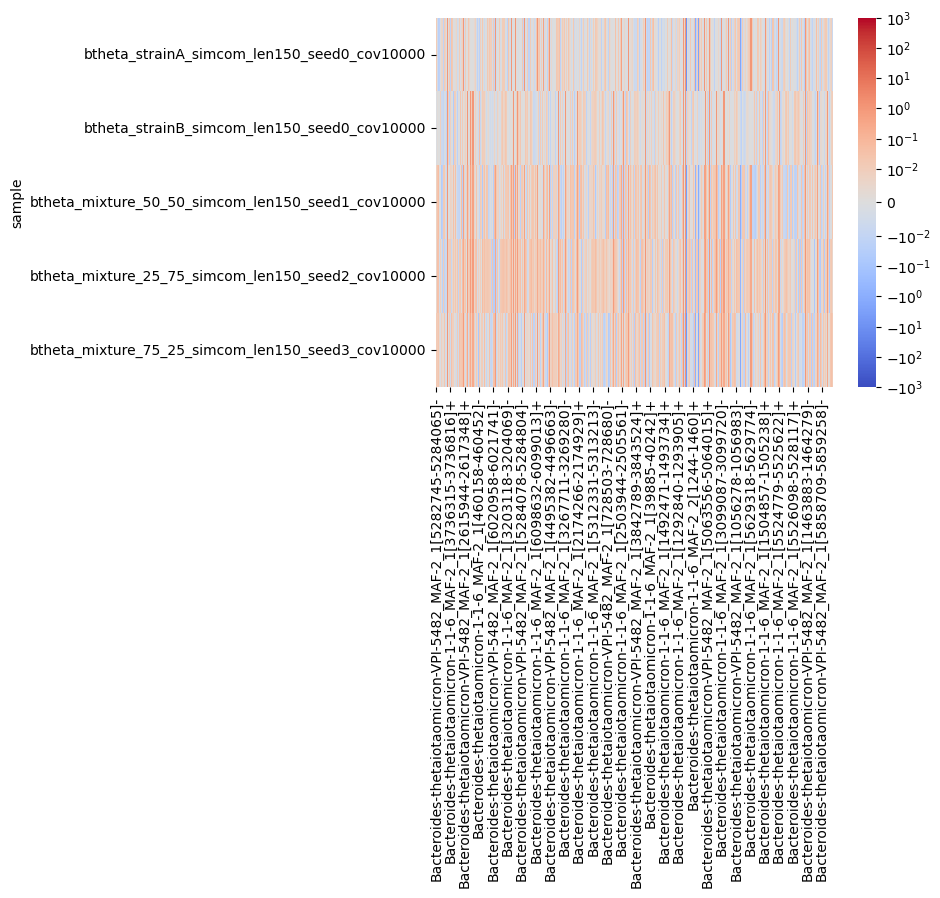

In [43]:
x0, y0 = _ref_pred.align(_tool_pred, fill_value=0)
_resid = x0 - y0
sns.heatmap(
    _resid.T.sample(min(1000, len(_resid)), axis="columns"),
    norm=mpl.colors.SymLogNorm(linthresh=1e-2, vmin=-1000, vmax=1000),
    cmap="coolwarm",
)

In [44]:
# error_result = {}
estimate_result = {}

tool_match_weight_list = [
    (
        "expect",
        match_ref.assign(key=lambda x: x.genome),
        known_rabund
    ),
    (
        "strainzip",
        match_strainzip.assign(key=lambda x: x.vertex),
        strainzip_normalized_depth,
    ),
    (
        "megahit",
        match_megahit.assign(key=lambda x: x.vertex),
        megahit_normalized_depth,
    ),
]


with tqdm(total=len(tool_match_weight_list) * len(thresh_list)) as pbar:
    for thresh_name, _min_identity, _min_coverage in thresh_list:
        _selector = lambda x: (x.identity >= _min_identity) & (
            x.qcoverage >= _min_coverage
        )

        if match_ref[_selector].empty:
            print("No reference sequences match the selector.")
            continue

        # _ref_pred = predict_depth_from_match_and_weight2(
        #     match=match_ref.assign(key=lambda x: x.genome),
        #     weight=known_rabund,
        #     selector=_selector,
        # )
        # estimate_result[('expected', thresh_name, _min_identity, _min_coverage)] = _ref_pred.rename_axis('bench')

        for tool_name, match, weight in tool_match_weight_list:
            _tool_pred = predict_depth_from_match_and_weight2(
                match=match,
                weight=weight,
                selector=_selector,
            )

            estimate_result[(tool_name, thresh_name)] = _tool_pred.rename_axis(index='bench', columns='sample')
            pbar.update()
            
#             x0, y0 = _ref_pred.align(_tool_pred, fill_value=0)
#             d0 = pd.DataFrame(
#                 dict(
#                     expected=x0.rename_axis(index="bench").stack().values,
#                     estimated=y0.rename_axis(index="bench").stack().values,
#                 ),
#                 index=x0.rename_axis(index="bench").stack().index,
#             ).assign(
#                 abs_resid=lambda x: np.abs(x.estimated - x.expected),
#                 sqr_resid=lambda x: np.square(x.estimated - x.expected),
#                 sqr_expect=lambda x: np.square(x.expected),
#             )

#             error_result[(thresh_name, min_coverage, min_identity, tool_name)] = (
#                 pd.DataFrame(
#                     dict(
#                         mean_abs_residual_bench_depth=(
#                             d0.abs_resid.unstack("sample")
#                             .groupby(bench_to_genome)
#                             .mean()
#                             .stack()
#                         ),
#                         mean_square_residual_bench_depth=(
#                             d0.sqr_resid.unstack("sample")
#                             .groupby(bench_to_genome)
#                             .mean()
#                             .stack()
#                         ),
#                         mean_expected_bench_depth=(
#                             d0.expected.unstack("sample")
#                             .groupby(bench_to_genome)
#                             .mean()
#                             .stack()
#                         ),
#                         mean_square_expected_bench_depth=(
#                             d0.sqr_expect.unstack("sample")
#                             .groupby(bench_to_genome)
#                             .mean()
#                             .stack()
#                         ),
#                     )
#                 )
#             )
#             pbar.update()

estimate_result = pd.concat(
    estimate_result, names=["tool", "thresh"]
).stack().to_xarray().fillna(0)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:01<00:00, 12.82it/s]


<Axes: xlabel='None-thresh', ylabel='tool-sample'>

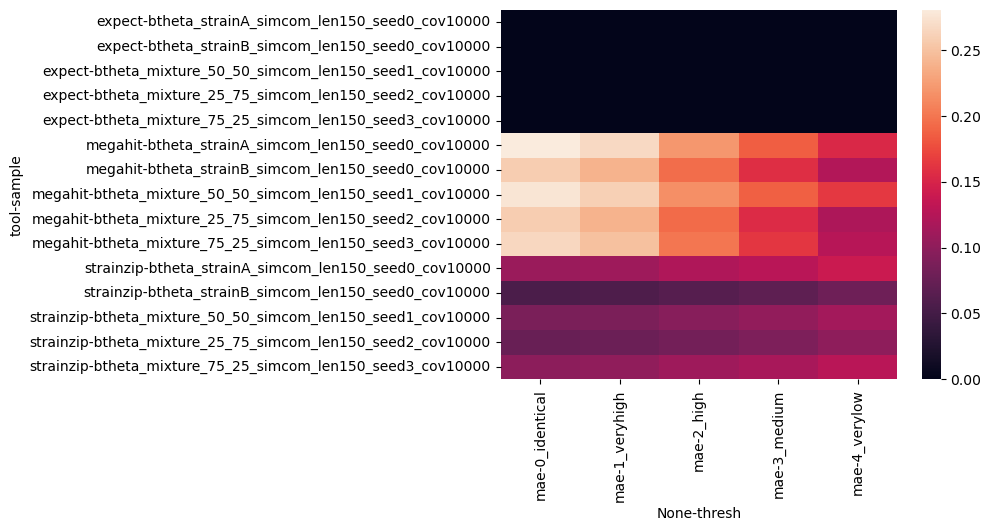

In [45]:
error_result = estimate_result - estimate_result.sel(tool='expect')

d = error_result.pipe(abs).mean("bench").to_dataframe(name='mae')
sns.heatmap(d.unstack('thresh'))

In [46]:
_bench_depth_total = estimate_result.transpose('tool', 'thresh', 'sample', 'bench') * benchmark_sequence_length.rename_axis('bench').to_xarray()
_bench_depth_true = _bench_depth_total.sel(tool='expect')
_bench_depth_error = _bench_depth_total.sel(tool=['megahit', 'strainzip']) - _bench_depth_true

In [47]:
_bench_depth_abs_error = _bench_depth_error.pipe(np.abs)
_bench_to_genome_operator = bench_to_genome.rename_axis('bench').reset_index().assign(val=1).set_index(['bench', 'genome']).val.to_xarray().fillna(0)
_per_genome_bench_depth_abs_error = _bench_depth_abs_error @ _bench_to_genome_operator
_per_genome_bench_depth_total = _bench_depth_true @ _bench_to_genome_operator

_per_genome_bench_depth_normalized_absolute_error = _per_genome_bench_depth_abs_error.sum("sample") / _per_genome_bench_depth_total.sum("sample")

<Axes: xlabel='thresh', ylabel='tool-genome'>

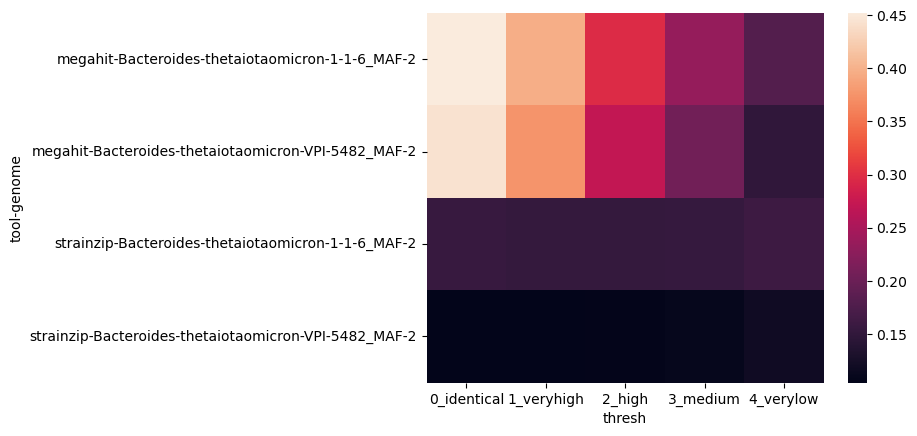

In [48]:
d = _per_genome_bench_depth_normalized_absolute_error.to_series().unstack('thresh')
sns.heatmap(d)

In [80]:
# WORKHERE

thresh = '0_identical'

_mean_rabund = known_rabund.loc[mgen_group.index].mean().rename(lambda x: x.replace('-', '_'))

d0 = _per_genome_bench_depth_normalized_absolute_error.sel(thresh=thresh).to_series().unstack('tool').rename_axis(index='genome_id').rename(lambda x: x.replace('-', '_')).assign(mean_rabund=_mean_rabund)

d0.to_csv('fig/normalized_absolute_error_id100_sim1.tsv', sep='\t')

/tmp/bsmith/ipykernel_1837364/3453142341.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  ax.scatter(d.megahit, d.strainzip, color='k', norm=mpl.colors.PowerNorm(1/3), s=5)


Text(0.5, 1.0, 'Normalized Error')

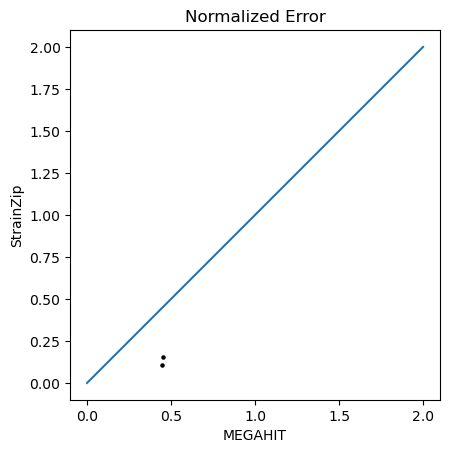

In [78]:
# c = _per_genome_bench_depth_total.sum('sample').sel(thresh=thresh)

d = d0

fig, ax = plt.subplots()
ax.scatter(d.megahit, d.strainzip, color='k', norm=mpl.colors.PowerNorm(1/3), s=5)
# ax.scatter(d.loc[genome_id_list].megahit, d.loc[genome_id_list].strainzip, color='tab:orange', norm=mpl.colors.PowerNorm(1/3))

ax.plot([0, 2], [0, 2])
ax.set_aspect(1)
plt.xlabel('MEGAHIT')
plt.ylabel('StrainZip')
plt.title('Normalized Error')

Text(0.5, 1.0, 'Normalized Error')

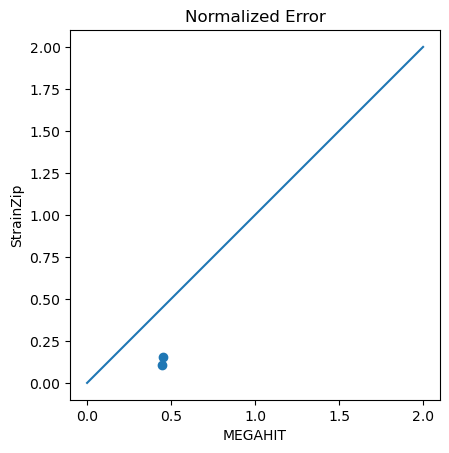

In [49]:
thresh = '0_identical'

d = _per_genome_bench_depth_normalized_absolute_error.sel(thresh=thresh).to_series().unstack('tool')
c = _per_genome_bench_depth_total.sum('sample').sel(thresh=thresh)


fig, ax = plt.subplots()
_mappable = ax.scatter(d.megahit, d.strainzip, color='tab:blue')
# fig.colorbar(_mappable)
ax.plot([0, 2], [0, 2])
ax.set_aspect(1)
plt.xlabel('MEGAHIT')
plt.ylabel('StrainZip')
plt.title('Normalized Error')

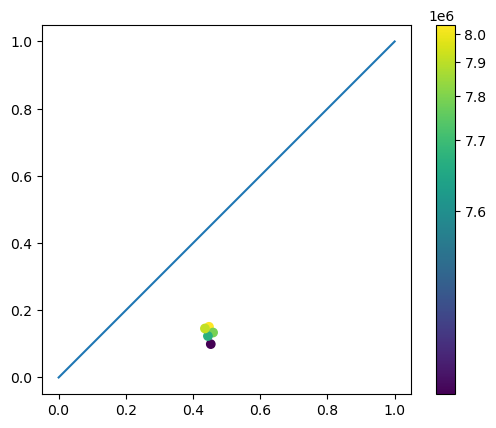

In [50]:
_per_genome_bench_depth_normalized_absolute_error2 = _per_genome_bench_depth_abs_error.sum("genome") / _per_genome_bench_depth_total.sum("genome")

thresh = '0_identical'

d = _per_genome_bench_depth_normalized_absolute_error2.sel(thresh=thresh).to_series().unstack('tool')
c = _per_genome_bench_depth_total.sum('genome').sel(thresh=thresh)


fig, ax = plt.subplots()
_mappable = ax.scatter(d.megahit, d.strainzip, c=c, norm=mpl.colors.PowerNorm(1/3))
fig.colorbar(_mappable)
ax.plot([0, 1], [0, 1])
ax.set_aspect(1)

megahit SignificanceResult(statistic=0.5780416285259989, pvalue=0.0) PearsonRResult(statistic=0.529583468889833, pvalue=0.0)
strainzip SignificanceResult(statistic=0.8403654771349872, pvalue=0.0) PearsonRResult(statistic=0.5301164029512189, pvalue=0.0)


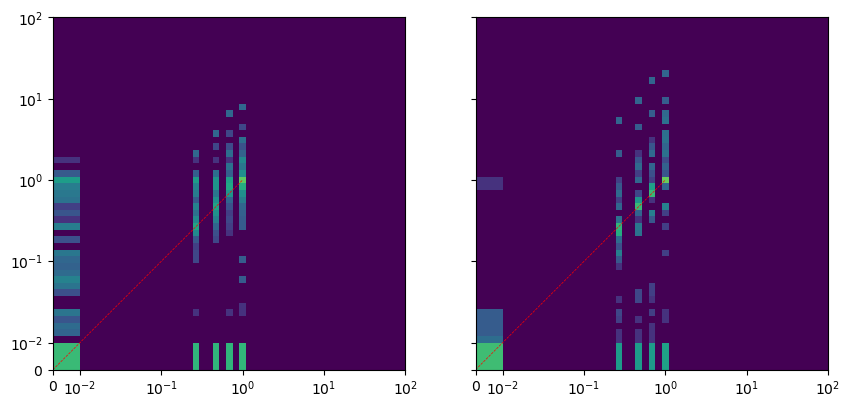

In [51]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 5))


thresh = '0_identical'

d = estimate_result
x = d.sel(tool='expect', thresh=thresh).to_series()



bins = [0] + list(np.logspace(-2, 2))


for ax, tool in zip(axs, ['megahit', 'strainzip']):
    y = d.sel(tool=tool, thresh=thresh).to_series()
    print(tool, sp.stats.spearmanr(x, y), sp.stats.pearsonr(x, y))
    ax.hist2d(x, y, bins=bins, norm=mpl.colors.SymLogNorm(1, vmin=1e-1, vmax=1e6))
    ax.set_xscale('symlog', linthresh=1e-2, linscale=0.3)
    ax.set_yscale('symlog', linthresh=1e-2, linscale=0.3)
    ax.set_aspect(1)
    ax.plot([0, 1], [0, 1], color='r', linestyle='--', lw=0.5)

# QUAST

In [52]:
genome_coverage = []

for tool, stem in [
    ("megahit", "megahit-full-k111"),
    (
        "strainzip",
        f"ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0",  # .contigs-d0",
    ),
]:
    for ident_string in ["10000", "9990", "9950", "9900", "9800"]:
        d = pd.read_table(
            f"data/group/{group}/r.proc.{stem}.quast-{group}-i{ident_string}.d/summary/TSV/Genome_fraction.tsv",
            na_values=["-", ""],
        ).fillna(0)
        d.columns = ["genome_id", "genome_percent"]
        d = d.assign(
            min_identity=int(ident_string) / 10000,
            genome_fraction=lambda x: x.genome_percent / 100,
            tool=tool,
            # sim_depth=int(cov_string) / 100,
        )
        genome_coverage.append(d)

genome_coverage = pd.concat(genome_coverage).set_index(['genome_id', 'tool', 'min_identity']).genome_fraction
genome_coverage.unstack(['genome_id', 'tool']).sort_index(axis=1)

genome_id    Bacteroides_thetaiotaomicron_1_1_6_MAF_2            \
tool                                          megahit strainzip   
min_identity                                                      
0.980                                         0.81894   0.99223   
0.990                                         0.81177   0.99228   
0.995                                         0.72893   0.99120   
0.999                                         0.44711   0.97449   
1.000                                         0.23367   0.94920   

genome_id    Bacteroides_thetaiotaomicron_VPI_5482_MAF_2            
tool                                             megahit strainzip  
min_identity                                                        
0.980                                            0.90145   0.99451  
0.990                                            0.87805   0.99457  
0.995                                            0.80796   0.99309  
0.999                                            0.39491   0.99199  
1.000                                            0.17741   0.97861

In [70]:
# WORKHERE: Add sequencing depth information for each genome and size the points based on that.

min_identity = 1.0

_mean_rabund = known_rabund.loc[mgen_group.index].mean().rename(lambda x: x.replace('-', '_'))
d0 = genome_coverage.xs(min_identity, level='min_identity').unstack().assign(mean_rabund=_mean_rabund)

d0.to_csv('fig/quast_genome_coverage_id100_sim1.tsv', sep='\t')

0.0 -0.7583650000000001


Text(0.5, 1.0, 'Un-covered Genome Length')

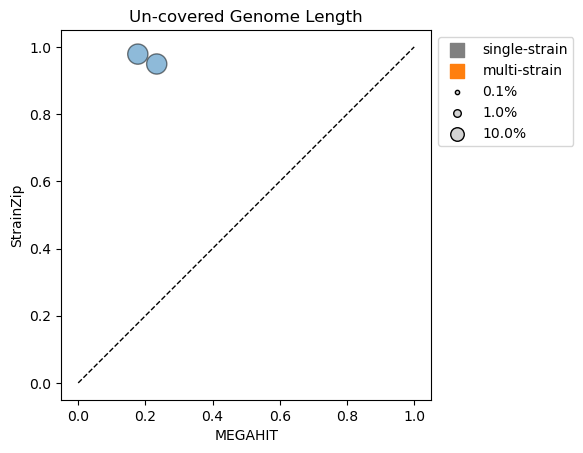

In [71]:
def _rabund_to_size(x):
    return np.sqrt(x) * 300

d = d0.assign(s=d0.mean_rabund.pipe(_rabund_to_size))

x = d['megahit']
y = d['strainzip']

print((y < x).mean(), (x - y).median())


fig, ax = plt.subplots()
ax.scatter('megahit', 'strainzip', data=d, color='tab:blue', edgecolor='k', s='s', alpha=0.5, label='__nolegend__')
ax.plot([0, 1], [0, 1], lw=1, linestyle='--', color='k')
ax.set_aspect(1)
ax.set_xlabel('MEGAHIT')
ax.set_ylabel('StrainZip')

ax.scatter([], [], color='grey', marker='s', label='single-strain', s=100)
ax.scatter([], [], color='tab:orange', marker='s', label='multi-strain', s=100)
for _rabund in [0.001, 0.01, 0.1]:
    ax.scatter([], [], color='lightgrey', edgecolor='k', s=_rabund_to_size(_rabund), label=f'{_rabund:.01%}')
ax.legend(bbox_to_anchor=(1, 1))
ax.set_title('Un-covered Genome Length')

1.0 0.7583650000000001


Text(0.5, 1.0, 'Genome Coverage')

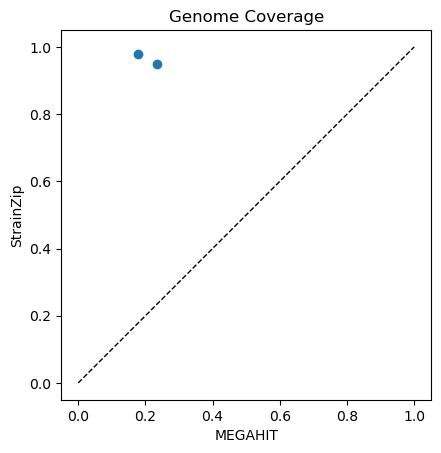

In [53]:
min_identity = 1.0
d = genome_coverage.to_xarray().sel(min_identity=min_identity)

x = d.sel(tool='megahit')
y = d.sel(tool='strainzip')

print((y > x).mean().values, (y - x).median().values)

plt.scatter(x, y, color='tab:blue')
plt.plot([0, 1], [0, 1], lw=1, linestyle='--', color='k')
plt.gca().set_aspect(1)
plt.xlabel('MEGAHIT')
plt.ylabel('StrainZip')
plt.title('Genome Coverage')

In [54]:
genome_nga50 = []

for tool, stem in [
    ("megahit", "megahit-full-k111"),
    (
        "strainzip",
        f"ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0",  # .contigs-d0",
    ),
]:
    for ident_string in ["10000", "9990", "9950", "9900", "9800"]:
        d = pd.read_table(
            f"data/group/{group}/r.proc.{stem}.quast-{group}-i{ident_string}.d/summary/TSV/NGA50.tsv",
            na_values=["-", ""],
        ).fillna(0)
        d.columns = ["genome_id", "nga50"]
        d = d.assign(
            min_identity=int(ident_string) / 10000,
            tool=tool,
            # sim_depth=int(cov_string) / 100,
        )
        genome_nga50.append(d)

genome_nga50 = pd.concat(genome_nga50).set_index(['genome_id', 'tool', 'min_identity']).nga50
genome_nga50.unstack(['genome_id', 'tool']).sort_index(axis=1)

genome_id    Bacteroides_thetaiotaomicron_1_1_6_MAF_2            \
tool                                          megahit strainzip   
min_identity                                                      
0.980                                         21371.0  100400.0   
0.990                                         21371.0  100400.0   
0.995                                         19642.0  100400.0   
0.999                                             0.0   99392.0   
1.000                                             0.0   68196.0   

genome_id    Bacteroides_thetaiotaomicron_VPI_5482_MAF_2            
tool                                             megahit strainzip  
min_identity                                                        
0.980                                            28266.0  155421.0  
0.990                                            28025.0  155421.0  
0.995                                            28025.0  155421.0  
0.999                                                0.0  155421.0  
1.000                                                0.0   81208.0

1.0 74702.0


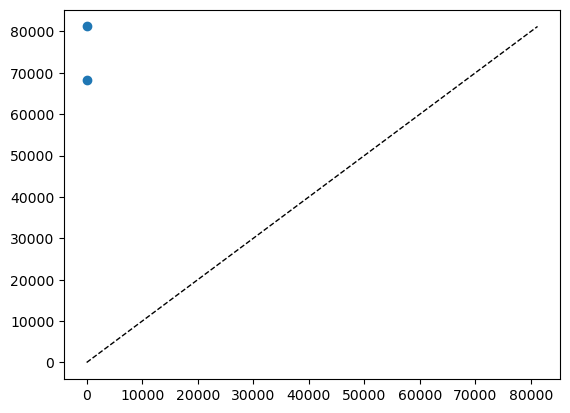

In [72]:
min_identity = 0.98
d = genome_nga50.to_xarray().sel(min_identity=min_identity)

x = d.sel(tool='megahit')
y = d.sel(tool='strainzip')

print((y > x).mean().values, (y - x).median().values)

plt.scatter(x, y)
plt.plot([0, d.max()], [0, d.max()], lw=1, linestyle='--', color='k')

In [56]:
genome_duplication_ratio = []

for tool, stem in [
    ("megahit", "megahit-full-k111"),
    (
        "strainzip",
        f"ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0",  # .contigs-d0",
    ),
]:
    for ident_string in ["10000", "9990", "9950", "9900", "9800"]:
        d = pd.read_table(
            f"data/group/{group}/r.proc.{stem}.quast-{group}-i{ident_string}.d/summary/TSV/Duplication_ratio.tsv",
            na_values=["-", ""],
        ).fillna(0)
        d.columns = ["genome_id", "duplication_ratio"]
        d = d.assign(
            min_identity=int(ident_string) / 10000,
            tool=tool,
            # sim_depth=int(cov_string) / 100,
        )
        genome_duplication_ratio.append(d)

genome_duplication_ratio = pd.concat(genome_duplication_ratio).set_index(['genome_id', 'tool', 'min_identity']).duplication_ratio
genome_duplication_ratio.unstack(['genome_id', 'tool']).sort_index(axis=1)

genome_id    Bacteroides_thetaiotaomicron_1_1_6_MAF_2            \
tool                                          megahit strainzip   
min_identity                                                      
0.980                                           1.019     6.574   
0.990                                           1.016     6.428   
0.995                                           1.011     5.899   
0.999                                           1.007     4.442   
1.000                                           1.009     2.388   

genome_id    Bacteroides_thetaiotaomicron_VPI_5482_MAF_2            
tool                                             megahit strainzip  
min_identity                                                        
0.980                                              1.021     7.249  
0.990                                              1.018     7.206  
0.995                                              1.013     6.642  
0.999                                              1.007     4.759  
1.000                                              1.011     2.550

In [57]:
genome_num_misassemblies = []

for tool, stem in [
    ("megahit", "megahit-full-k111"),
    (
        "strainzip",
        f"ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0",  # .contigs-d0",
    ),
]:
    for ident_string in ["10000", "9990", "9950", "9900", "9800"]:
        d = pd.read_table(
            f"data/group/{group}/r.proc.{stem}.quast-{group}-i{ident_string}.d/summary/TSV/num_misassemblies.tsv",
            na_values=["-", ""],
        ).fillna(0)
        d.columns = ["genome_id", "num_misassemblies"]
        d = d.assign(
            min_identity=int(ident_string) / 10000,
            tool=tool,
            # sim_depth=int(cov_string) / 100,
        )
        genome_num_misassemblies.append(d)

genome_num_misassemblies = pd.concat(genome_num_misassemblies).set_index(['genome_id', 'tool', 'min_identity']).num_misassemblies
genome_num_misassemblies.unstack(['genome_id', 'tool']).sort_index(axis=1)

genome_id    Bacteroides_thetaiotaomicron_1_1_6_MAF_2            \
tool                                          megahit strainzip   
min_identity                                                      
0.980                                              12       209   
0.990                                              12       155   
0.995                                              11       134   
0.999                                               8        50   
1.000                                               1        13   

genome_id    Bacteroides_thetaiotaomicron_VPI_5482_MAF_2            
tool                                             megahit strainzip  
min_identity                                                        
0.980                                                  8       146  
0.990                                                  6       136  
0.995                                                  5        95  
0.999                                                  3        37  
1.000                                                  2        14

# Fraction of Reads Mapping to Erroneous Sequences

### MEGAHIT

In [58]:
megahit_sequence_length = pd.read_table(
    f"data/group/{group}/r.proc.megahit-full-k111.nlength.tsv",
    names=["gene", "nlength"],
    index_col="gene",
).nlength
benchmark_sequence_length

gene
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[0-1413]+            1413
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[1554-2292]-          738
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[2576-5114]+         2538
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[5245-7927]+         2682
Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1[8139-9153]+         1014
                                                               ... 
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[30017-30524]-     507
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[30528-31236]-     708
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[31246-31456]-     210
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[31442-32009]-     567
Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_2[31992-33039]-    1047
Name: nlength, Length: 10536, dtype: int64

In [59]:
megahit_to_ref = (
    pd.read_table(
        f"data/group/{group}/r.proc.megahit-full-k111.all_refs-blastn.tsv",
        names=blastn_columns,
    )
    .join(megahit_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        vertex=lambda x: x.sseqid,  # Equivalent to the "genome" field for the ref_match table. I'll join depths based on this.
    )
)

megahit_to_ref  # [lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)]

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,vertex
0,k111_112,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1,99.550,222,1,0,1,222,5152801,5153022,2.200000e-113,405.0,222,0.99550,1.000000,0,5152800,222,5153022,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1
1,k111_112,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,96.396,222,8,0,1,222,4239033,4238812,1.040000e-101,366.0,222,0.96396,1.000000,0,4239032,222,4238812,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1
2,k111_1093,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,100.000,251,0,0,1,251,6101581,6101331,4.100000e-131,464.0,251,1.00000,1.000000,0,6101580,251,6101331,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1
3,k111_1093,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1,99.602,251,1,0,1,251,6346422,6346172,1.910000e-129,459.0,251,0.99602,1.000000,0,6346421,251,6346172,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1
4,k111_1174,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1,100.000,309,0,0,1,309,3855365,3855057,2.940000e-163,571.0,309,1.00000,1.000000,0,3855364,309,3855057,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9140,k111_1172,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,100.000,111,0,0,1,111,6265940,6265830,4.640000e-51,206.0,38799,1.00000,0.002861,0,6265939,111,6265830,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1
9141,k111_1172,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,95.276,127,6,0,118,244,1471669,1471795,6.000000e-50,202.0,38799,0.95276,0.003273,117,1471668,244,1471795,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1
9142,k111_1172,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,79.661,118,12,7,12141,12246,5233594,5233477,1.370000e-11,75.0,38799,0.79661,0.003041,12140,5233593,12246,5233477,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1
9143,k111_1173,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1,100.000,680,0,0,1,680,5486893,5486214,0.000000e+00,1256.0,680,1.00000,1.000000,0,5486892,680,5486214,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1


In [60]:
megahit_aligned_bases = (megahit_contig_depth.T * megahit_sequence_length).sum(1)
megahit_missaligned_bases = (
    megahit_contig_depth.T.drop(
        columns=megahit_to_ref[
            lambda x: (x.identity >= 0.99) & (x.qcoverage >= coverage_thresh)
        ].qseqid.unique(),
        errors="ignore",
    )
    * megahit_sequence_length
).sum(1)
megahit_well_aligned_frac = 1 - (megahit_missaligned_bases / megahit_aligned_bases)
megahit_well_aligned_frac

sample
btheta_mixture_25_75_simcom_len150_seed2_cov10000    0.851441
btheta_mixture_50_50_simcom_len150_seed1_cov10000    0.843720
btheta_mixture_75_25_simcom_len150_seed3_cov10000    0.839511
btheta_strainA_simcom_len150_seed0_cov10000          0.834267
btheta_strainB_simcom_len150_seed0_cov10000          0.857123
dtype: float64

### StrainZip

In [61]:
strainzip_sequence_length = pd.read_table(
    f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.nlength.tsv",
    names=["gene", "nlength"],
    index_col="gene",
).nlength
strainzip_sequence_length

gene
4214    251424
4108    251424
4097    251424
3840    251424
4093    251424
         ...  
2763       111
2764       111
2765       111
2766       111
790        111
Name: nlength, Length: 4378, dtype: int64

In [62]:
strainzip_to_ref = (
    pd.read_table(
        f"data/group/{group}/r.proc.ggcat-{graph_type}.notips-2.{smoothing}.unzip-{deconv}.contigs-d0.all_refs-blastn.tsv",
        names=blastn_columns,
    )
    .join(strainzip_sequence_length.rename("qlen"), on="qseqid")
    .assign(
        identity=lambda x: x.pident / 100,
        qcoverage=lambda x: x.length / x.qlen,
        qleft=lambda x: x.qstart - 1,
        sleft=lambda x: x.sstart - 1,
        qright=lambda x: x.qend,
        sright=lambda x: x.send,
        vertex=lambda x: x.sseqid,  # Equivalent to the "genome" field for the ref_match table. I'll join depths based on this.
    )
)

strainzip_to_ref  # [lambda x: (x.qcoverage >= min_coverage) & (x.identity >= min_identity)]

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,identity,qcoverage,qleft,sleft,qright,sright,vertex
0,4214,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,99.706,192073,556,7,1,192069,982280,790212,0.000000e+00,351600.0,251424,0.99706,0.763941,0,982279,192069,790212,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1
1,4214,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,99.998,41617,1,0,192063,233679,4961321,5002937,0.000000e+00,76847.0,251424,0.99998,0.165525,192062,4961320,233679,5002937,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1
2,4214,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,97.985,17763,317,22,233666,251424,790220,772495,0.000000e+00,30781.0,251424,0.97985,0.070650,233665,790219,251424,772495,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1
3,4214,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,97.118,347,10,0,100493,100839,859847,859501,9.200000e-165,586.0,251424,0.97118,0.001380,100492,859846,100839,859501,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1
4,4214,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,97.118,347,10,0,122434,122780,881788,881442,9.200000e-165,586.0,251424,0.97118,0.001380,122433,881787,122780,881442,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58700,2766,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1,100.000,110,0,0,1,110,6340311,6340202,3.870000e-53,204.0,111,1.00000,0.990991,0,6340310,110,6340202,Bacteroides-thetaiotaomicron-1-1-6_MAF-2_1
58701,790,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,100.000,111,0,0,1,111,3903867,3903757,1.080000e-53,206.0,111,1.00000,1.000000,0,3903866,111,3903757,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1
58702,790,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,100.000,111,0,0,1,111,6084564,6084454,1.080000e-53,206.0,111,1.00000,1.000000,0,6084563,111,6084454,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1
58703,790,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1,100.000,110,0,0,1,110,727362,727471,3.870000e-53,204.0,111,1.00000,0.990991,0,727361,110,727471,Bacteroides-thetaiotaomicron-VPI-5482_MAF-2_1


In [63]:
strainzip_aligned_kmers = (vertex_depth.T * strainzip_sequence_length).sum(1)
strainzip_missaligned_kmers = (
    vertex_depth.T.drop(
        columns=strainzip_to_ref[
            lambda x: (x.identity >= 0.99) & (x.qcoverage >= coverage_thresh)
        ].qseqid.unique(),
        errors="ignore",
    )
    * strainzip_sequence_length
).sum(1)
strainzip_well_aligned_frac = 1 - (
    strainzip_missaligned_kmers / strainzip_aligned_kmers
)
strainzip_well_aligned_frac

sample
btheta_strainA_simcom_len150_seed0_cov10000          0.935911
btheta_strainB_simcom_len150_seed0_cov10000          0.909332
btheta_mixture_50_50_simcom_len150_seed1_cov10000    0.919786
btheta_mixture_25_75_simcom_len150_seed2_cov10000    0.913772
btheta_mixture_75_25_simcom_len150_seed3_cov10000    0.925460
dtype: float64

### Combined

In [64]:
missaligned = []

for tool_name, match, weight, length in [
    (
        "strainzip",
        strainzip_to_ref.assign(key=lambda x: x.vertex),
        vertex_depth.T * strainzip_sequence_length,
        strainzip_sequence_length,
    ),
    (
        "megahit",
        megahit_to_ref.assign(key=lambda x: x.vertex),
        megahit_contig_depth.T * megahit_sequence_length,
        megahit_sequence_length,
    ),
]:
    for thresh_name, _min_identity, _min_coverage in thresh_list:
        _selector = lambda x: (x.identity >= _min_identity) & (
            x.qcoverage >= _min_coverage
        )
        missaligned_weight = (
            weight.drop(
                columns=match[_selector].qseqid.unique(),
                errors="ignore",
            )
        ).sum(1)
        missaligned_length = (
            length.drop(
                match[_selector].qseqid.unique(),
                errors="ignore",
            )
        ).sum()

        for sample in missaligned_weight.index:
            missaligned.append(
                dict(
                    sample=sample,
                    thresh=thresh_name,
                    min_coverage=_min_coverage,
                    min_identity=_min_identity,
                    tool=tool_name,
                    missaligned_weight_frac=missaligned_weight.loc[sample]
                    / weight.loc[sample].sum(),
                    missaligned_length_frac=missaligned_length / length.sum(),
                )
            )

missaligned = pd.DataFrame(missaligned)

Text(0.5, 0, 'min_identity')

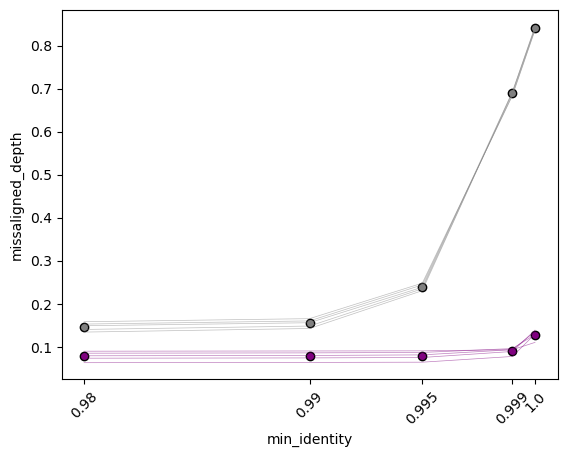

In [65]:
if not missaligned.empty:
    d = (
        missaligned.set_index(["tool", "sample", "min_identity"])
        .sort_index()
        .missaligned_weight_frac.unstack("min_identity")
    )

    for tool in ["megahit", "strainzip"]:
        d2 = d.xs(tool)
        for sample in d2.index:
            d3 = d2.loc[sample]
            plt.plot(
                d3,
                # linestyle=linestyle_palette[tool],
                lw=0.5,
                color={'strainzip': 'purple', 'megahit': 'grey'}[tool],
                # marker="o",
                # markerfacecolor=facecolor_palette[tool],
                alpha=0.5,
            )
        plt.scatter(
            d2.columns,
            d2.mean(0),
            # color="k",
            # lw=3,
            # linestyle=linestyle_palette[tool],
            # markerfacecolor=facecolor_palette[tool],
            marker="o",
            edgecolor='k',
            color={'strainzip': 'purple', 'megahit': 'grey'}[tool],
            label=tool,
        )

plt.xticks(d3.index, d3.index, rotation=45)

plt.ylabel("missaligned_depth")
plt.xlabel("min_identity")
# plt.legend()

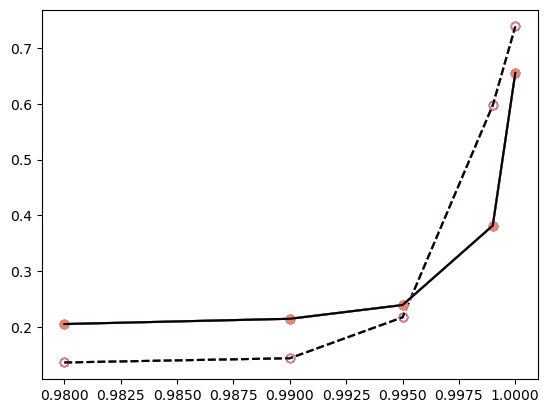

In [66]:
if not missaligned.empty:
    d = (
        missaligned.set_index(["tool", "sample", "min_identity"])
        .sort_index()
        .missaligned_length_frac.unstack("min_identity")
    )

    for tool in ["megahit", "strainzip"]:
        d2 = d.xs(tool)
        for sample in d2.index:
            d3 = d2.loc[sample]
            plt.plot(
                d3,
                linestyle=linestyle_palette[tool],
                c=sample_palette[sample],
                marker="o",
                markerfacecolor=facecolor_palette[tool],
            )
        plt.plot(
            d2.mean(0),
            color="k",
            linestyle=linestyle_palette[tool],
            markerfacecolor=facecolor_palette[tool],
        )